# EfficientDet 기반 제조 영상 분석 최적화 [프로젝트]

차량 탐지 데이터셋(Vehicles_Detection)으로 EfficientDet-D0를 학습하고 평가한다. 저장소는 `zylo117/Yet-Another-EfficientDet-Pytorch`를 쓴다.

실행 전에 구글 드라이브 `내 드라이브/cv_projects/`에 `archive.zip`을 올려두고, 런타임을 T4 GPU로 바꾼 뒤 `런타임 → 모두 실행`한다.

## 0. 프로젝트 목표

차량 탐지 데이터셋으로 EfficientDet-D0 모델을 학습하고 평가한다. 어떻게 학습시키는지, 어떤 평가를 내리는지 확인한다.

## 1. 환경 준비

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/cv_projects'
OUT   = f'{DRIVE}/efficientdet'          # 학습 결과가 여기 쌓입니다
PROJECT = 'my_car_detect_proj'

import os
os.makedirs(OUT, exist_ok=True)
assert os.path.exists(f'{DRIVE}/archive.zip'), 'archive.zip을 드라이브 cv_projects 폴더에 먼저 올려주세요'
print('준비 완료')

Mounted at /content/drive
준비 완료


In [3]:
%cd /content
!rm -rf Yet-Another-EfficientDet-Pytorch
!git clone -q https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch.git
%cd Yet-Another-EfficientDet-Pytorch
!pip -q install pycocotools tensorboardX webcolors

/content
/content/Yet-Another-EfficientDet-Pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 1.5 MB/s eta 0:00:00


In [4]:
# 사전학습 가중치
!mkdir -p weights
!wget -q https://github.com/zylo117/Yet-Another-Efficient-Pytorch/releases/download/1.0/efficientdet-d0.pth -O weights/efficientdet-d0.pth
!ls -lh weights

total 16M
-rw-r--r-- 1 root root 16M Dec  7  2021 efficientdet-d0.pth


In [5]:
# 최신 torch/numpy와 맞지 않는 부분을 고칩니다
!sed -i 's/patience=3, verbose=True/patience=3/' train.py
!sed -i 's/torch\.load(weights_path)/torch.load(weights_path, weights_only=False)/' train.py
!sed -i "s/torch\.load(weights_path, map_location=torch.device('cpu'))/torch.load(weights_path, map_location=torch.device('cpu'), weights_only=False)/" coco_eval.py
!sed -i -E 's/np\.(int|float|bool)\b/\1/g' utils/utils.py efficientdet/utils.py efficientdet/dataset.py
print('패치 완료')

패치 완료


In [6]:
# 데이터 압축 해제
!mkdir -p datasets
!cp {DRIVE}/archive.zip datasets/
!unzip -q -o datasets/archive.zip -d datasets/car_detect
!ls datasets/car_detect

Apply_Grayscale     Sample_Video_HighQuality.mp4
No_Apply_Grayscale  SampleVideo_LowQuality.mp4


## 2. 데이터 확인

흑백 적용본(`Apply_Grayscale`, v9i)으로 학습한다. 컬러본(`No_Apply_Grayscale`, v8i)은 비교 실험 후보로 남겨둔다.

In [7]:
import json, glob, os
from collections import Counter

SRC = 'datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco'

for split in ['train', 'valid', 'test']:
    j = json.load(open(f'{SRC}/{split}/_annotations.coco.json'))
    cats = {c['id']: c['name'] for c in j['categories']}
    cnt = Counter(cats[a['category_id']] for a in j['annotations'])
    print(f'{split:5s}: 이미지 {len(j["images"]):3d}장, 박스 {len(j["annotations"]):4d}개  {dict(cnt)}')
print('categories:', cats)

train: 이미지 136장, 박스 2724개  {'Car': 2023, 'Pickup': 251, 'Motorcycle': 355, 'Bus': 31, 'Truck': 64}
valid: 이미지  28장, 박스  563개  {'Car': 398, 'Pickup': 59, 'Motorcycle': 92, 'Bus': 6, 'Truck': 8}
test : 이미지  13장, 박스  254개  {'Truck': 3, 'Car': 179, 'Pickup': 29, 'Motorcycle': 38, 'Bus': 5}
categories: {0: 'cars', 1: 'Bus', 2: 'Car', 3: 'Motorcycle', 4: 'Pickup', 5: 'Truck'}


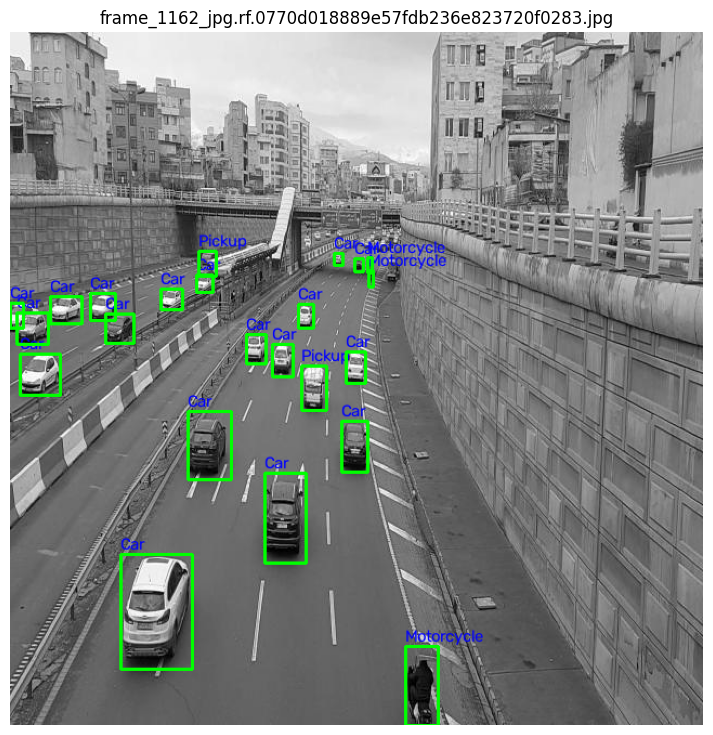

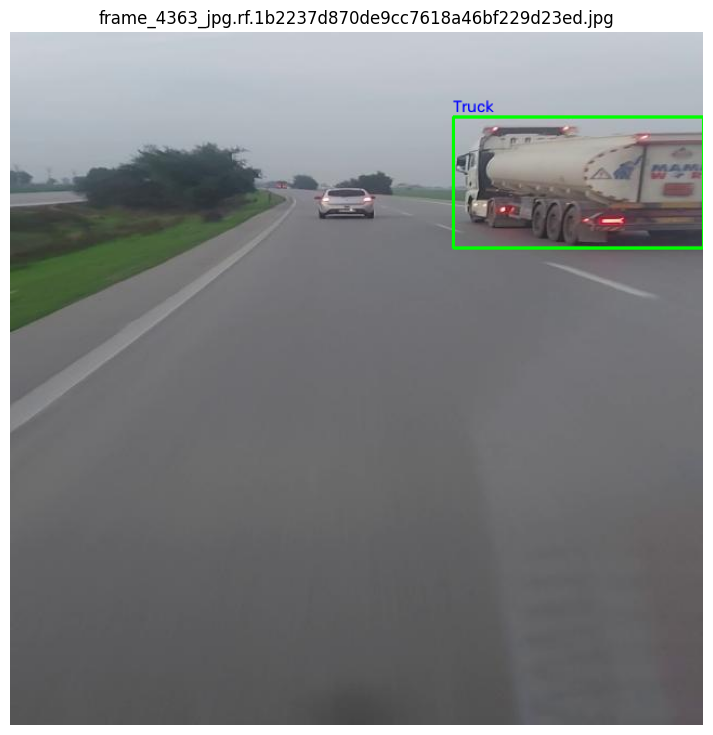

In [8]:
# 정답 박스가 어떻게 그려져 있는지 한 장 확인
import cv2, matplotlib.pyplot as plt

def show_gt(split, idx=0):
    j = json.load(open(f'{SRC}/{split}/_annotations.coco.json'))
    info = j['images'][idx]
    img = cv2.imread(f'{SRC}/{split}/{info["file_name"]}')
    cats = {c['id']: c['name'] for c in j['categories']}
    for a in j['annotations']:
        if a['image_id'] != info['id']: continue
        x, y, w, h = map(int, a['bbox'])
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, cats[a['category_id']], (x, y-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    plt.figure(figsize=(9, 9)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(info['file_name']); plt.axis('off'); plt.show()

show_gt('train', 0)
show_gt('test', 0)

Car가 2,023개, Bus가 31개로 65배 차이가 난다. Bus는 136장 안에서 31번밖에 안 나오니 거의 못 배웠을 것으로 예상한다. 다만 이 저장소의 평가는 클래스별 점수를 따로 보여주지 않아서 확인하지는 못했다.

train[0]은 고가도로 위에서 내려다본 CCTV이고 test[0]은 차 안에서 찍은 블랙박스라 구도가 완전히 다르다. 이런 장면을 본 적 없는 모델이 어떻게 할지 궁금했는데, 테스트 2 그림에서 frame_4363의 예측이 0개였다. 136장 중 이런 구도가 거의 없어서 못 배운 것이다.

## 3. 학습 준비

In [9]:
# 학습 데이터 자체로 mean/std 계산
import numpy as np
from tqdm import tqdm

def compute_mean_std(image_dir):
    means, stds = [], []
    for p in tqdm(sorted(glob.glob(f'{image_dir}/*.jpg')), desc='mean/std'):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB) / 255.0
        means.append(img.mean(axis=(0, 1))); stds.append(img.std(axis=(0, 1)))
    return np.mean(means, 0).round(4).tolist(), np.mean(stds, 0).round(4).tolist()

MEAN, STD = compute_mean_std(f'{SRC}/train')
print('mean', MEAN); print('std ', STD)

mean/std: 100%|██████████| 136/136 [00:04<00:00, 27.90it/s]

mean [0.4646, 0.4709, 0.4692]
std  [0.1642, 0.1633, 0.1625]


픽셀 값은 0~255다. 신경망은 입력이 0 근처에서 위아래로 비슷하게 퍼져 있을 때 잘 배우기 때문에, 들어가기 전에 `(픽셀 값 - 평균) / 표준편차`로 바꾼다. 이 평균과 표준편차를 학습에 쓰는 바로 그 이미지로 계산한 것이다. 강사님 노트북은 컬러본으로 계산하고 흑백본으로 학습해서 서로 달랐다.

In [10]:
# 저장소가 요구하는 폴더 구조로 복사
#   datasets/my_car_detect_proj/{train,valid,test}/*.jpg
#   datasets/my_car_detect_proj/annotations/instances_{train,valid,test}.json
import shutil
DST = f'datasets/{PROJECT}'
os.makedirs(f'{DST}/annotations', exist_ok=True)
for split in ['train', 'valid', 'test']:
    os.makedirs(f'{DST}/{split}', exist_ok=True)
    for p in glob.glob(f'{SRC}/{split}/*.jpg'):
        shutil.copy(p, f'{DST}/{split}/')
    shutil.copy(f'{SRC}/{split}/_annotations.coco.json', f'{DST}/annotations/instances_{split}.json')
    print(split, len(os.listdir(f'{DST}/{split}')), '장')

j = json.load(open(f'{DST}/annotations/instances_train.json'))
OBJ_LIST = [c['name'] for c in sorted(j['categories'], key=lambda c: c['id'])]
print('obj_list:', OBJ_LIST)

train 136 장
valid 28 장
test 13 장
obj_list: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']


In [11]:
# 프로젝트 설정 파일 생성
# 앵커는 강사님이 데이터 분석으로 정한 값을 그대로 씀
ANCHOR_SCALES = '[0.54, 1.0, 2.13]'
ANCHOR_RATIOS = '[(0.52, 1.0), (0.67, 1.0), (0.82, 1.0)]'

yml = f'''project_name: {PROJECT}
train_set: train
val_set: valid
num_gpus: 1
mean: {MEAN}
std: {STD}
anchors_scales: '{ANCHOR_SCALES}'
anchors_ratios: '{ANCHOR_RATIOS}'
obj_list: {OBJ_LIST}
'''
os.makedirs('projects', exist_ok=True)
open(f'projects/{PROJECT}.yml', 'w').write(yml)
print(yml)

project_name: my_car_detect_proj
train_set: train
val_set: valid
num_gpus: 1
mean: [0.4646, 0.4709, 0.4692]
std: [0.1642, 0.1633, 0.1625]
anchors_scales: '[0.54, 1.0, 2.13]'
anchors_ratios: '[(0.52, 1.0), (0.67, 1.0), (0.82, 1.0)]'
obj_list: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']



mean/std 세 채널 값이 거의 같아서 흑백 데이터임을 확인했다.

앵커는 COCO 기본값 대신 강사님이 데이터 분석으로 정한 값을 썼다. 정답 박스 중앙값이 17px에 비율 0.67로 작고 세로로 길어서, 앵커도 그에 맞춘 것이다. 의도는 맞다.

다만 scales의 2.13은 가장 큰 격자에서 화면(640px)보다 큰 앵커를 만든다. 테스트 2 그림 frame_1806 왼쪽 위의 거대한 박스가 그것으로 보인다. 정답과 매칭될 일이 없는 앵커라 학습이 안 되고 엉뚱한 박스를 내놓는다. 다음에는 기본 앵커로 한 번 돌려서 비교해 보고 싶다.

## 4. 학습

1단계는 분류 헤드만(`head_only`), 2단계는 전체를 학습합니다.
결과는 드라이브 `cv_projects/efficientdet/logs/`에 저장됩니다.

In [12]:
# 1단계: 헤드만 10 epoch
!python train.py -c 0 -p {PROJECT} --head_only True --lr 1e-3 --batch_size 16 \
  --load_weights weights/efficientdet-d0.pth --num_epochs 10 --save_interval 100 --num_workers 2 \
  --saved_path {OUT}/logs --log_path {OUT}/logs

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Warning] Ignoring Error(s) in loading state_dict for EfficientDetBackbone:
	size mismatch for classifier.header.pointwise_conv.conv.weight: copying a param with shape torch.Size([810, 64, 1, 1]) from checkpoint, the shape in current model is torch.Size([54, 64, 1, 1]).
	size mismatch for classifier.header.pointwise_conv.conv.bias: copying a param with shape torch.Size([810]) from checkpoint, the shape in current model is torch.Size([54]).
[Warning] Don't panic if you see this, this might be because you load a pretrained weights with different number of classes. The rest of the weights should be loaded already.
[Info] loaded weights: efficientdet-d0.pth, resuming checkpoint from step: 0
[Info] freezed backbone
  0% 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:238: UserWarning: Converting a tensor 

헤드를 COCO 90클래스에서 6클래스로 새로 만들어서 처음엔 아무것도 몰랐다. 그래서 백본을 얼리고 헤드만 먼저 10 epoch 학습시킨 뒤 전체를 풀었다. 즉 아무것도 모르는 헤드가 아니라 우리 클래스에 맞는 헤드로 갈아끼우는 단계다.

In [13]:
# 가장 최근 체크포인트 찾기 (파일명이 데이터 크기에 따라 달라지므로 하드코딩하지 않습니다)
def latest_ckpt():
    files = glob.glob(f'{OUT}/logs/{PROJECT}/efficientdet-d0_*.pth')
    return max(files, key=lambda p: int(p.rsplit('_', 1)[-1].split('.')[0]))

ckpt1 = latest_ckpt(); print('1단계 결과:', ckpt1)

1단계 결과: /content/drive/MyDrive/cv_projects/efficientdet/logs/my_car_detect_proj/efficientdet-d0_29_240.pth


In [14]:
# 2단계: 전체 30 epoch
!python train.py -c 0 -p {PROJECT} --head_only False --lr 1e-3 --batch_size 16 \
  --load_weights "{ckpt1}" --num_epochs 30 --save_interval 100 --num_workers 2 \
  --saved_path {OUT}/logs --log_path {OUT}/logs

BEST = latest_ckpt(); print('최종 가중치:', BEST)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Info] loaded weights: efficientdet-d0_29_240.pth, resuming checkpoint from step: 240
최종 가중치: /content/drive/MyDrive/cv_projects/efficientdet/logs/my_car_detect_proj/efficientdet-d0_29_240.pth


이제는 헤드뿐만 아니라 백본까지 전부 같이 학습시켜 미세조정이 들어가고 최종 가중치가 나온다.

1단계 val 총손실이 25,870에서 160으로 내려왔다. 그런데 나눠 보면 분류 손실이 25,867 → 158이고 회귀 손실은 3.2 → 1.7이다. 회귀는 처음부터 작다. 박스 위치를 조정하는 능력은 COCO에서 배운 것이 그대로 살아 있고, 분류 헤드만 새로 만들어서 아무것도 몰랐기 때문이다. 헤드를 갈아끼웠다는 것이 숫자로 보인다.

160도 아직 크다. 2단계에서 전체를 풀어 더 내려야 한다.

## 5. 테스트 1: 검증 세트 평가

In [15]:
!python coco_eval.py -c 0 -p {PROJECT} -w "{BEST}"

running coco-style evaluation on project my_car_detect_proj, weights /content/drive/MyDrive/cv_projects/efficientdet/logs/my_car_detect_proj/efficientdet-d0_29_240.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 28/28 [00:09<00:00,  2.86it/s]
Loading and preparing results...
DONE (t=0.39s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.07s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.041
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.004
 Average Reca

valid mAP50이 0.010, mAP50-95가 0.006이다. 크기별로 보면 small은 0.000이고 medium이 0.041로 그나마 높다. 이 데이터는 대부분 작은 차라서 small이 0이면 사실상 못 잡는 것이다.

어제 같은 설정으로 돌렸을 때는 mAP50이 0.059였다. 같은 설정인데 결과가 이렇게 다른 것은 학습이 짧아서 실행마다 결과가 흔들린다는 뜻이다.

## 6. 테스트 1: 테스트 세트 평가

In [16]:
# val_set만 test로 바꾼 설정 파일을 하나 더 만들어 평가
open(f'projects/{PROJECT}_test.yml', 'w').write(yml.replace('val_set: valid', 'val_set: test'))
!python coco_eval.py -c 0 -p {PROJECT}_test -w "{BEST}"

running coco-style evaluation on project my_car_detect_proj_test, weights /content/drive/MyDrive/cv_projects/efficientdet/logs/my_car_detect_proj/efficientdet-d0_29_240.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 13/13 [00:08<00:00,  1.53it/s]
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.33s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.008
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.048
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average

테스트 세트도 mAP50 0.012로 검증(0.010)과 같다. 모델이 검증에만 못 하는 게 아니라 전반적으로 배경과 물체를 못 가른다. 데이터 분할 문제가 아니라 학습 자체의 문제로 보인다. 특히 small은 아예 탐지하지 못한다.

## 7. 예측 결과 눈으로 확인

In [17]:
import torch, yaml
from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess

params = yaml.safe_load(open(f'projects/{PROJECT}.yml'))
model = EfficientDetBackbone(compound_coef=0, num_classes=len(params['obj_list']),
                             ratios=eval(params['anchors_ratios']), scales=eval(params['anchors_scales']))
model.load_state_dict(torch.load(BEST, map_location='cpu', weights_only=False))
model.requires_grad_(False); model.eval(); model = model.cuda()

def predict(img_path, threshold=0.4, iou_threshold=0.2):
    ori, framed, metas = preprocess(img_path, max_size=512)
    x = torch.stack([torch.from_numpy(f).cuda() for f in framed], 0).float().permute(0, 3, 1, 2)
    with torch.no_grad():
        feats, reg, cls, anchors = model(x)
        out = postprocess(x, anchors, reg, cls, BBoxTransform(), ClipBoxes(), threshold, iou_threshold)
    return ori[0], invert_affine(metas, out)[0]

test_imgs = sorted(glob.glob(f'{DST}/test/*.jpg'))[:6]
gt = json.load(open(f'{DST}/annotations/instances_test.json'))
id2file = {i['id']: i['file_name'] for i in gt['images']}
gt_by_file = {}
for a in gt['annotations']:
    gt_by_file.setdefault(id2file[a['image_id']], []).append(a['bbox'])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, p in zip(axes.flat, test_imgs):
    img, pred = predict(p)
    img = img.copy()
    for x, y, w, h in gt_by_file.get(os.path.basename(p), []):          # 정답: 초록
        cv2.rectangle(img, (int(x), int(y)), (int(x+w), int(y+h)), (0, 255, 0), 2)
    for j in range(len(pred['rois'])):                                     # 예측: 노랑
        x1, y1, x2, y2 = pred['rois'][j].astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(img, f"{params['obj_list'][pred['class_ids'][j]]} {pred['scores'][j]:.2f}",
                    (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1)
    ax.imshow(img); ax.set_title(os.path.basename(p)[:30]); ax.axis('off')
plt.suptitle('초록 = 정답, 노랑 = 예측'); plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

테스트 1 가중치로 신뢰도 0.4 이상만 그렸더니 노란 박스가 하나도 없었다. 모델이 0.4 이상으로 확신하는 물체가 6장 중 한 개도 없다는 뜻이다. 그래서 그림에는 초록 정답 박스만 남았다.

처음에는 이 초록 박스를 예측으로 착각하고 "잘 맞췄다"고 생각했다. 제목의 한글이 Colab에서 네모로 깨져서 "초록 = 정답, 노랑 = 예측"을 읽지 못한 탓이다. 그림을 볼 때는 범례부터 확인해야 한다는 것을 배웠다.

결과적으로 이 셀은 정답 라벨이 어떻게 그려져 있는지 확인하는 셀이 됐다. 작은 차, 겹친 차, 가장자리에 걸린 차, 가로등에 가려진 트럭까지 사람이 다 표시해 두었는데, 모델은 그중 하나도 0.4 이상으로 잡지 못했다.

## 테스트 2: epoch를 늘려 다시 학습

테스트 1은 헤드 10 + 전체 30 epoch, 총 320걸음이었다. 배경을 배경으로 판단하는 것을 충분히 배우지 못해 mAP50이 0.01에 머물렀다. 다른 설정은 그대로 두고 epoch만 늘린다. 헤드 20 + 전체 80. 결과는 `run2/` 폴더에 따로 저장해서 테스트 1 파일과 섞이지 않게 한다.

In [19]:
RUN2 = f'{OUT}/run2'
os.makedirs(RUN2, exist_ok=True)

!python train.py -c 0 -p {PROJECT} --head_only True --lr 1e-3 --batch_size 16 \
  --load_weights weights/efficientdet-d0.pth --num_epochs 20 --save_interval 1000 --num_workers 2 \
  --saved_path {RUN2} --log_path {RUN2}

def latest_in(folder):
    files = glob.glob(f'{folder}/{PROJECT}/efficientdet-d0_*.pth')
    return max(files, key=lambda f: int(f.rsplit('_', 1)[-1].split('.')[0]))

ck1 = latest_in(RUN2); print('1단계:', os.path.basename(ck1))

!python train.py -c 0 -p {PROJECT} --head_only False --lr 1e-3 --batch_size 16 \
  --load_weights "{ck1}" --num_epochs 100 --save_interval 1000 --num_workers 2 \
  --saved_path {RUN2} --log_path {RUN2}

BEST2 = latest_in(RUN2); print('테스트 2 최종:', os.path.basename(BEST2))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Warning] Ignoring Error(s) in loading state_dict for EfficientDetBackbone:
	size mismatch for classifier.header.pointwise_conv.conv.weight: copying a param with shape torch.Size([810, 64, 1, 1]) from checkpoint, the shape in current model is torch.Size([54, 64, 1, 1]).
	size mismatch for classifier.header.pointwise_conv.conv.bias: copying a param with shape torch.Size([810]) from checkpoint, the shape in current model is torch.Size([54]).
[Warning] Don't panic if you see this, this might be because you load a pretrained weights with different number of classes. The rest of the weights should be loaded already.
[Info] loaded weights: efficientdet-d0.pth, resuming checkpoint from step: 0
[Info] freezed backbone
  0% 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:238: UserWarning: Converting a tensor 

In [21]:
print('===== valid =====')
!python coco_eval.py -c 0 -p {PROJECT} -w "{BEST2}"
print('===== test =====')
!python coco_eval.py -c 0 -p {PROJECT}_test -w "{BEST2}"

===== valid =====
running coco-style evaluation on project my_car_detect_proj, weights /content/drive/MyDrive/cv_projects/efficientdet/run2/my_car_detect_proj/efficientdet-d0_87_704.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 28/28 [00:07<00:00,  3.68it/s]
Loading and preparing results...
DONE (t=0.11s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.95s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.158
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.265
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.185
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.054
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.340
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0

In [22]:
model2 = EfficientDetBackbone(compound_coef=0, num_classes=len(params['obj_list']),
                              ratios=eval(params['anchors_ratios']), scales=eval(params['anchors_scales']))
model2.load_state_dict(torch.load(BEST2, map_location='cpu', weights_only=False))
model2.requires_grad_(False); model2.eval(); model2 = model2.cuda()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, p in zip(axes.flat, test_imgs):
    ori, framed, metas = preprocess(p, max_size=512)
    x = torch.stack([torch.from_numpy(f).cuda() for f in framed], 0).float().permute(0, 3, 1, 2)
    with torch.no_grad():
        feats, reg, cls, anchors = model2(x)
        pred = invert_affine(metas, postprocess(x, anchors, reg, cls, BBoxTransform(), ClipBoxes(), 0.2, 0.5))[0]
    img = ori[0].copy()
    for bx, by, bw, bh in gt_by_file.get(os.path.basename(p), []):
        cv2.rectangle(img, (int(bx), int(by)), (int(bx+bw), int(by+bh)), (0, 255, 0), 2)
    for j in range(len(pred['rois'])):
        x1, y1, x2, y2 = pred['rois'][j].astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)
    ax.imshow(img); ax.set_title(f"{os.path.basename(p)[:24]}  pred={len(pred['rois'])}"); ax.axis('off')
plt.suptitle('TEST 2: green = GT, yellow = pred (conf >= 0.2)'); plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

epoch를 100까지 올리니 valid mAP50이 0.010에서 0.265로 26배, test는 0.012에서 0.144로 12배 올랐다. 최종 가중치가 `_87_704`로 epoch 87까지 val 손실이 계속 개선됐다는 뜻이고, 100에서 멈춘 게 아직 덜 배운 상태일 수 있다는 신호다.

그림에서 확인되는 것은 세 가지다. 도로에 거대한 예측 박스가 하나 남아 있고, 차량 하나에 박스가 2~3개씩 겹쳐서 나오고, 멀리 있는 작은 차량들은 여전히 감지하지 못한다. 또 블랙박스 구도는 본 적이 없어 예측이 0개다.

학습량 부족이라는 가설은 맞았다. 다만 거대 박스와 작은 차는 epoch로 해결되지 않았으니 다른 원인이 남아 있다. 시간이 있다면 학습량을 더 높여서 해보고 싶다.

## 8. 결과 백업

In [18]:
!cp projects/{PROJECT}.yml {OUT}/
!cp -r datasets/{PROJECT}/annotations {OUT}/
print('드라이브에 저장됨:', OUT)
!ls -R {OUT} | head -30

드라이브에 저장됨: /content/drive/MyDrive/cv_projects/efficientdet
/content/drive/MyDrive/cv_projects/efficientdet:
annotations
logs
my_car_detect_proj.yml

/content/drive/MyDrive/cv_projects/efficientdet/annotations:
instances_test.json
instances_train.json
instances_valid.json

/content/drive/MyDrive/cv_projects/efficientdet/logs:
my_car_detect_proj

/content/drive/MyDrive/cv_projects/efficientdet/logs/my_car_detect_proj:
efficientdet-d0_0_8.pth
efficientdet-d0_10_88.pth
efficientdet-d0_1_16.pth
efficientdet-d0_11_96.pth
efficientdet-d0_12_100.pth
efficientdet-d0_12_104.pth
efficientdet-d0_13_112.pth
efficientdet-d0_14_120.pth
efficientdet-d0_15_128.pth
efficientdet-d0_16_136.pth
efficientdet-d0_17_144.pth
efficientdet-d0_18_152.pth
efficientdet-d0_19_160.pth
efficientdet-d0_20_168.pth
efficientdet-d0_21_176.pth
efficientdet-d0_22_184.pth


## 9. 목표 기준 평가

학습시키는 방법은 확인했다. YOLOv8이 한 줄로 끝내던 것을 여기서는 저장소 패치, 폴더 재배치, mean/std 계산, 설정 파일 작성, 헤드 먼저 학습 후 전체 학습으로 나눠서 직접 했다. 특히 epoch 수가 결과를 좌우한다는 것을 40과 100을 비교해서 확인했다.

평가 방법도 확인했다. COCO 지표 12줄에서 AP50, AP50-95, 크기별 AP를 읽는 법을 익혔고, 숫자만 보지 않고 정답과 예측을 그림으로 겹쳐서 대조했다.

목표에 없었는데 배운 것이 더 많다. 손실이 정상적으로 내려가도 mAP가 0.01일 수 있다는 것, 그림이 좋아 보여도 초록인지 노랑인지부터 봐야 한다는 것, 같은 설정으로 두 번 돌려도 결과가 다르다는 것, 그리고 epoch 하나가 26배를 가른다는 것이다.

## 10. 개인 회고 (KPT)

**Keep**

- mean/std를 학습에 쓰는 바로 그 데이터로 직접 계산한 것. 강사님 노트북처럼 다른 데이터로 잰 값을 쓰지 않았다.
- 헤드만 먼저 학습하고 그다음 전체를 학습하는 두 단계 방식. 새로 만든 헤드가 백본을 흔들지 않게 한다.
- 결과가 안 나왔을 때 설정을 이것저것 만지지 않고 epoch부터 늘려본 것. 그 하나로 26배가 올랐다.

**Problem**

- 손실은 정상적으로 내려갔는데 mAP가 0.01이었다. 손실만 보고 잘 됐다고 판단할 뻔했다.
- 그림에서 초록 정답 박스를 모델 예측으로 착각했다. 한글 제목이 깨져서 범례를 못 읽었다.
- 흑백본으로 학습했는데 컬러본이었으면 달랐을지 확인하지 못했다.

**Try**

- epoch를 300까지 늘려본다. 테스트 2에서 87 epoch까지 val 손실이 계속 개선됐으므로 100은 아직 덜 배운 상태다.
- 앵커를 COCO 기본값으로 되돌려 비교한다. 거대 박스가 사라지는지 본다.
- 클래스별 AP를 출력하도록 평가 코드를 고쳐서 Bus(31개)가 실제로 얼마나 안 되는지 확인한다.